In [7]:
!rm -rf /content/ag062

!/content/micromamba/bin/micromamba create -y -p /content/ag062 -c conda-forge python=3.9.16 pip

!/content/micromamba/bin/micromamba run -p /content/ag062 python -m pip install \
  "pip==23.3.2" "setuptools==68.2.2" "wheel==0.41.3"

!/content/micromamba/bin/micromamba run -p /content/ag062 python -m pip --version

[+] 0.0s
Fetch Shard Index for conda-forge/linux-64                                                ✔ Done (0.1 sec)
Fetch Shard Index for conda-forge/noarch                                                  ✔ Done (0.1 sec)
Fetching and Parsing Packages' Shards                                                     ✔ Done (1.4 sec)

Resolving Environment                                                                     ✔ Done (0.2 sec)

Transaction

  Prefix: /content/ag062

  Updating specs:

   - python=3.9.16
   - pip


  Package               Version  Build                 Channel          Size
──────────────────────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge      29kB
  + bzip2                 1.0.8  hda65f42_9            conda-forge     260kB
  + ca-certificates   2026.6.17  hbd8a1cb_0            conda-forge     1

In [8]:
!/content/micromamba/bin/micromamba run -p /content/ag062 python -m pip install \
  "autogluon.vision==0.6.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.2/248.2 kB 35.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.5/113.5 kB 15.5 MB/s eta 0:00:00
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
INFO: pip is looking at multiple versions of albumentations to determine which version is compatible with other requirements. This could take a while.
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
     ━━

In [9]:
!LD_LIBRARY_PATH=/content/ag062/lib:$LD_LIBRARY_PATH MPLBACKEND=Agg \
/content/micromamba/bin/micromamba run -p /content/ag062 python -c "from autogluon.vision import ObjectDetector; print('ObjectDetector OK')"

INFO:torch.distributed.nn.jit.instantiator:Created a temporary directory at /tmp/tmpbajalukb
INFO:torch.distributed.nn.jit.instantiator:Writing /tmp/tmpbajalukb/_remote_module_non_scriptable.py
ObjectDetector OK


# Benchmarking VOC12 reduced datset with AutoGluon
# Using presets

In [45]:
# !python --version

In [11]:
!nvidia-smi

Thu Jun 25 19:49:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   38C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [12]:
!lsb_release -a

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.4 LTS
Release:	22.04
Codename:	jammy


# Connecting to google drive and directing to folders with valtrain and test sets

In [13]:
from google.colab import drive
#! original
# drive.mount('/content/MyDrive')
#! modified
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Iinstalling CUDA

In [14]:
import os
os.chdir("/content")

!/content/micromamba/bin/micromamba run -p /content/ag062 python -m pip uninstall -y mxnet mxnet-cu112

!/content/micromamba/bin/micromamba run -p /content/ag062 python -m pip install --no-cache-dir --no-deps \
  "mxnet-cu112==1.9.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.4/499.4 MB 268.2 MB/s eta 0:00:00


Approximately 3 minutes to install

In [ ]:
# !pip install autogluon==0.6.2

Restart runtime after installing ipykernel (~13 seconds)

In [ ]:
# !pip install -U ipykernel

In [ ]:
# import autogluon as ag

In [44]:
# from autogluon.vision import ObjectDetector

Changing into directory where datasets are stored

In [15]:
#! original
# %cd /content/MyDrive/MyDrive/Colab Notebooks/benchmark_project/VOC12_reduced

#! modified
%cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced

/content/drive/.shortcut-targets-by-id/1-yxxtzF6J91Lo3VuIvi8tCZ0XAVFfTUH/Colab_Notebooks/benchmark_project/VOC12_reduced


In [16]:
import os

for file in os.getcwd():
  print(os.listdir())

['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag', 'voc12_detector.ag']
['_fiftyone_cache', '_checkpoints', 'VOC12_train', 'VOC12_validation', 'VOC12_test', 'bin', 'detector.ag

In [43]:
# #!sudo apt install tree
# !tree -d

In [17]:
import os

images_count = 0
annotation_count = 0

base_dir = "/content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced/VOC12_train/VOC2012"

images_dir = base_dir + "/JPEGImages/"
annotation_dir = base_dir + "/Annotations/"

for path in os.listdir(images_dir):
    if os.path.isfile(os.path.join(images_dir, path)):
        images_count += 1

for path in os.listdir(annotation_dir):
    if os.path.isfile(os.path.join(annotation_dir, path)):
        annotation_count += 1

print("Images count:", images_count)
print("Annotation count:", annotation_count)

Images count: 2758
Annotation count: 2758


### Trying to check the "trainval.txt" file and see if it has corresponding annotations (.xml) and images (.jpg) for each line listed.

In [18]:
def check_if_existsJPG(file_path, string):
    # check if the file exists in the given folder path
    return os.path.exists(os.path.join(file_path, string + ".jpg"))

def check_if_existsXML(file_path, string):
  return os.path.exists(os.path.join(file_path, string + ".xml"))

def read_strings_from_file(file_name):
    # read strings from a file, where each string is separated by a new line
    with open(file_name, "r") as file:
        strings = file.read().splitlines()
    return strings

def jpgCheck(strings_file, folder_path):
    # read strings from the given file
    strings = read_strings_from_file(strings_file)
    exists = 0
    nonexists = 0

    # check if the corresponding file with .jpg extension exists in the folder
    for string in strings:
        if check_if_existsJPG(folder_path, string):
            #print(f"{string}.jpg exists in {folder_path}")
            exists = exists + 1
        else:
            #print(f"{string}.jpg does not exist in {folder_path}")
            nonexists = nonexists + 1

    return exists, nonexists

def xmlCheck(strings_file, folder_path):
    # read strings from the given file
    strings = read_strings_from_file(strings_file)
    exists = 0
    nonexists = 0

    # check if the corresponding file with .jpg extension exists in the folder
    for string in strings:
        if check_if_existsXML(folder_path, string):
            #print(f"{string}.jpg exists in {folder_path}")
            exists = exists + 1
        else:
            #print(f"{string}.xml does not exist in {folder_path}")
            nonexists = nonexists + 1

    return exists, nonexists

In [19]:
base_dir = "/content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced/VOC12_train/VOC2012"

numExist = jpgCheck(
    base_dir + "/ImageSets/Main/train.txt",
    base_dir + "/JPEGImages"
)

print(numExist)

(2758, 0)


In [20]:
xmlExist = xmlCheck(
    base_dir + "/ImageSets/Main/train.txt",
    base_dir + "/Annotations"
)

print(xmlExist)

(2758, 0)


In [21]:
#! original
# %cd /content/MyDrive/MyDrive/Colab Notebooks/benchmark_project/VOC12_reduced/

#! modified
%cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced/

/content/drive/.shortcut-targets-by-id/1-yxxtzF6J91Lo3VuIvi8tCZ0XAVFfTUH/Colab_Notebooks/benchmark_project/VOC12_reduced


In [22]:
import os
print(os.getcwd())

/content/drive/.shortcut-targets-by-id/1-yxxtzF6J91Lo3VuIvi8tCZ0XAVFfTUH/Colab_Notebooks/benchmark_project/VOC12_reduced


### Main chunk of code for training. Below we are importing the dataset and running it. Will take some time.

In [23]:
!/content/micromamba/bin/micromamba install -y -p /content/ag062 -c conda-forge \
  cudatoolkit=11.2 cudnn=8

Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.4 sec)

Pinned packages:

  - python=3.9

Resolving Environment                                                                     ✔ Done (0.2 sec)

Transaction

  Prefix: /content/ag062

  Updating specs:

   - cudatoolkit=11.2
   - cudnn=8


  Package          Version  Build        Channel          Size
────────────────────────────────────────────────────────────────
  Install:
────────────────────────────────────────────────────────────────

  + cuda-version      11.2  hb11dac2_3   conda-forge      21kB
  + cudatoolkit     11.2.2  hc23eb0c_13  conda-forge     661MB
  + cudnn         8.9.7.29  hbc23b4c_3   conda-forge     465MB
  + libstdcxx-ng    15.2.0  hdf11a46_19  conda-

In [22]:
%%bash
set -e

cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced

export MPLBACKEND=Agg
export LD_LIBRARY_PATH=/content/ag062/lib:${LD_LIBRARY_PATH}

/content/micromamba/bin/micromamba run -p /content/ag062 python <<'PY'
from autogluon.vision import ObjectDetector
import traceback

dataset_train = ObjectDetector.Dataset.from_voc(root='VOC12_train/VOC2012', splits='train')
dataset_val = ObjectDetector.Dataset.from_voc(root='VOC12_validation/VOC2012', splits='validation')

detector = ObjectDetector()

try:
    detector.fit(
        train_data=dataset_train,
        tuning_data=dataset_val,
        presets='good_quality_fast_inference',
        ngpus_per_trial=1
    )
except Exception as e:
    traceback.print_exc()
    raise

# Saving model
savefile = 'voc12_detector.ag'
detector.save(savefile)
PY

learning rate from ``lr_scheduler`` has been overwritten by ``learning_rate`` in optimizer.
learning rate from ``lr_scheduler`` has been overwritten by ``learning_rate`` in optimizer.
learning rate from ``lr_scheduler`` has been overwritten by ``learning_rate`` in optimizer.
learning rate from ``lr_scheduler`` has been overwritten by ``learning_rate`` in optimizer.


/content/ag062/lib/python3.9/site-packages/gluoncv/__init__.py:40: UserWarning: Both `mxnet==1.9.1` and `torch==1.12.1+cu102` are installed. You might encounter increased GPU memory footprint if both framework are used at the same time.
  warnings.warn(f'Both `mxnet=={mx.__version__}` and `torch=={torch.__version__}` are installed. '
INFO:torch.distributed.nn.jit.instantiator:Created a temporary directory at /tmp/tmpj_crvnuc
INFO:torch.distributed.nn.jit.instantiator:Writing /tmp/tmpj_crvnuc/_remote_module_non_scriptable.py
In a future release ObjectDetector may be entirely reworked to use Torch as a backend.
This future change will likely be API breaking.Users should ensure they update their code that depends on ObjectDetector when upgrading to future AutoGluon releases.
For more information, refer to ObjectDetector refactor GitHub issue: https://github.com/autogluon/autogluon/issues/1559

Presets specified: ['good_quality_fast_inference']
Starting HPO experiments
  0%|          | 0/5

In [3]:
%%bash
cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced

cp -a detector.ag voc12_detector.ag

# Below I'm loading the model and seeing the score against the test dataset

In [24]:
%%bash
set -e

cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced

export MPLBACKEND=Agg
export LD_LIBRARY_PATH=/content/ag062/lib:${LD_LIBRARY_PATH}

/content/micromamba/bin/micromamba run -p /content/ag062 python <<'PY'
from autogluon.vision import ObjectDetector

savefile1 = 'voc12_detector.ag'

new_detector = ObjectDetector.load(savefile1)

dataset_test = ObjectDetector.Dataset.from_voc(
    root='VOC12_test/VOC2012',
    splits='test'
)

test_map = new_detector.evaluate(dataset_test)

print("mAP on test dataset: {}".format(test_map[1][-1]))
PY

mAP on test dataset: 0.009569962891420612


/content/ag062/lib/python3.9/site-packages/gluoncv/__init__.py:40: UserWarning: Both `mxnet==1.9.1` and `torch==1.12.1+cu102` are installed. You might encounter increased GPU memory footprint if both framework are used at the same time.
  warnings.warn(f'Both `mxnet=={mx.__version__}` and `torch=={torch.__version__}` are installed. '
INFO:torch.distributed.nn.jit.instantiator:Created a temporary directory at /tmp/tmpth4ew2im
INFO:torch.distributed.nn.jit.instantiator:Writing /tmp/tmpth4ew2im/_remote_module_non_scriptable.py
[19:51:22] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8907 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
INFO:root:Model file not found. Downloading.
100%|██████████| 57421/57421 [00:02<00:00, 19854.36KB/s]
/content/ag062/lib/python3.9/site-packages/mxnet/gluon/block.py:1784: UserWarning: Cannot decide type for the following arguments. Consider providing them as input:
	data: None
  input_sym_arg_type = i

In [42]:
# test_map = new_detector.evaluate(dataset_test, score_thresh=0.90)

In [41]:
# print("mAP on test dataset: {}".format(test_map[1][-1]))

In [40]:
# print(test_map)

In [39]:
# class_names = ['cat', 'bird', 'dog', 'sheep', 'bus', 'cow', 'aeroplane', 'train', 'horse', 'person', 'boat', 'motorbike', 'mAP']
# aps = [0.0032371189641219314, 0.0008340283569641369, 0.000251130085384229, 0.053158705701078585, 0.0022172949002217295, 0.0, 0.03441355999261969, 0.00089126559714795, 0.004958677685950413, 0.016890535741855797, 0.0, 0.9960474308300398, 0.09274164565461535]

# # Combine the class names and APs using the zip function
# results = zip(class_names, aps)

# # Format the output using f-strings
# print("Class\t\tAP")
# print("----\t\t--")
# for class_name, ap in results:
#     print(f"{class_name}\t\t{ap:.4f}")

In [38]:
# print("mAP on validation dataset: {}".format(validation_map[1][-1]))

In [37]:
# print(fit_summary1)

In [29]:
#! original
# image = '/content/MyDrive/MyDrive/Colab Notebooks/benchmark_project/VOC12_reduced/VOC12_test/VOC2012/JPEGImages/005791.jpg'

#! modified
image = '/content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced/VOC12_test/VOC2012/JPEGImages/test_000000_003761.jpg'

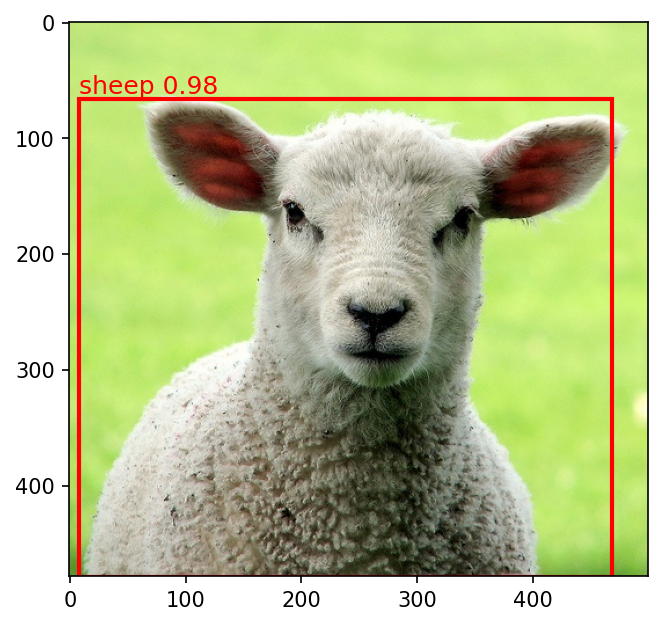

In [32]:
import subprocess
from IPython.display import Image as DisplayImage, display

script = r"""
from autogluon.vision import ObjectDetector
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

new_detector = ObjectDetector.load('voc12_detector.ag')

image_path = '/content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced/VOC12_test/VOC2012/JPEGImages/test_000000_003761.jpg'

image = np.array(Image.open(image_path))

result = new_detector.predict(image)

fig, ax = plt.subplots(1)
ax.imshow(image)

for i, row in result[result['predict_score'] > 0.9].iterrows():
    label = row['predict_class']
    score = row['predict_score']
    bbox = row['predict_rois']

    x1 = int(bbox['xmin'] * image.shape[1])
    y1 = int(bbox['ymin'] * image.shape[0])
    x2 = int(bbox['xmax'] * image.shape[1])
    y2 = int(bbox['ymax'] * image.shape[0])

    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f"{label} {score:.2f}", fontsize=12, color='r')

plt.savefig('/content/prediction_inline.png', bbox_inches='tight', dpi=150)
"""

cmd = f"""
cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced
export MPLBACKEND=Agg
export LD_LIBRARY_PATH=/content/ag062/lib:$LD_LIBRARY_PATH
/content/micromamba/bin/micromamba run -p /content/ag062 python - <<'PY'
{script}
PY
"""

subprocess.run(cmd, shell=True, check=True)
display(DisplayImage(filename="/content/prediction_inline.png"))

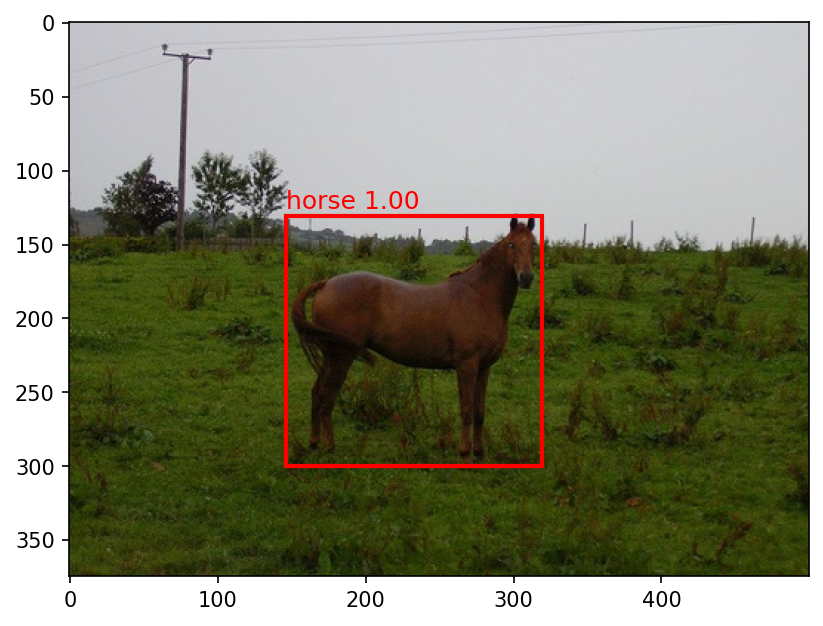

In [33]:
import subprocess
from IPython.display import Image as DisplayImage, display

script = r"""
from autogluon.vision import ObjectDetector
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

new_detector = ObjectDetector.load('voc12_detector.ag')

image_path = '/content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced/VOC12_test/VOC2012/JPEGImages/test_000298_000439.jpg'

image = np.array(Image.open(image_path))

result = new_detector.predict(image)

fig, ax = plt.subplots(1)
ax.imshow(image)

for i, row in result[result['predict_score'] > 0.9].iterrows():
    label = row['predict_class']
    score = row['predict_score']
    bbox = row['predict_rois']

    x1 = int(bbox['xmin'] * image.shape[1])
    y1 = int(bbox['ymin'] * image.shape[0])
    x2 = int(bbox['xmax'] * image.shape[1])
    y2 = int(bbox['ymax'] * image.shape[0])

    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f"{label} {score:.2f}", fontsize=12, color='r')

plt.savefig('/content/prediction_inline.png', bbox_inches='tight', dpi=150)
"""

cmd = f"""
cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced
export MPLBACKEND=Agg
export LD_LIBRARY_PATH=/content/ag062/lib:$LD_LIBRARY_PATH
/content/micromamba/bin/micromamba run -p /content/ag062 python - <<'PY'
{script}
PY
"""

subprocess.run(cmd, shell=True, check=True)
display(DisplayImage(filename="/content/prediction_inline.png"))

In [34]:
%%bash
set -e

cd /content/drive/MyDrive/Colab_Notebooks/benchmark_project/VOC12_reduced

export MPLBACKEND=Agg
export LD_LIBRARY_PATH=/content/ag062/lib:${LD_LIBRARY_PATH}

/content/micromamba/bin/micromamba run -p /content/ag062 python <<'PY'
from autogluon.vision import ObjectDetector

new_detector = ObjectDetector.load('voc12_detector.ag')

dataset_test = ObjectDetector.Dataset.from_voc(
    root='VOC12_test/VOC2012',
    splits='test'
)

bulk_result = new_detector.predict(dataset_test)

bulk_result.to_csv('bulk_results.csv', index=False)
dataset_test.to_csv('dataset_test.csv', index=False)

print("Saved:")
print("bulk_results.csv")
print("dataset_test.csv")
print()
print("Files in VOC12_reduced:")
PY

ls -lh bulk_results.csv dataset_test.csv

Saved:
bulk_results.csv
dataset_test.csv

Files in VOC12_reduced:
-rw------- 1 root root 1.9M Jun 25 20:39 bulk_results.csv
-rw------- 1 root root 123K Jun 25 20:39 dataset_test.csv


/content/ag062/lib/python3.9/site-packages/gluoncv/__init__.py:40: UserWarning: Both `mxnet==1.9.1` and `torch==1.12.1+cu102` are installed. You might encounter increased GPU memory footprint if both framework are used at the same time.
  warnings.warn(f'Both `mxnet=={mx.__version__}` and `torch=={torch.__version__}` are installed. '
INFO:torch.distributed.nn.jit.instantiator:Created a temporary directory at /tmp/tmpszspudvp
INFO:torch.distributed.nn.jit.instantiator:Writing /tmp/tmpszspudvp/_remote_module_non_scriptable.py
[20:29:33] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8907 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
/content/ag062/lib/python3.9/site-packages/mxnet/gluon/block.py:1784: UserWarning: Cannot decide type for the following arguments. Consider providing them as input:
	data: None
  input_sym_arg_type = in_param.infer_type()[0]
[20:29:40] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running perfor

In [ ]:
# result

In [36]:
# dataset_test

In [ ]:
# bulk_result = new_detector.predict(dataset_test)

In [35]:
# !ls

In [ ]:
# bulk_result.to_csv('bulk_results.csv', index=False)

In [ ]:
# dataset_test.to_csv('dataset_test.csv', index=False)